In [ ]:
!pip install padasip

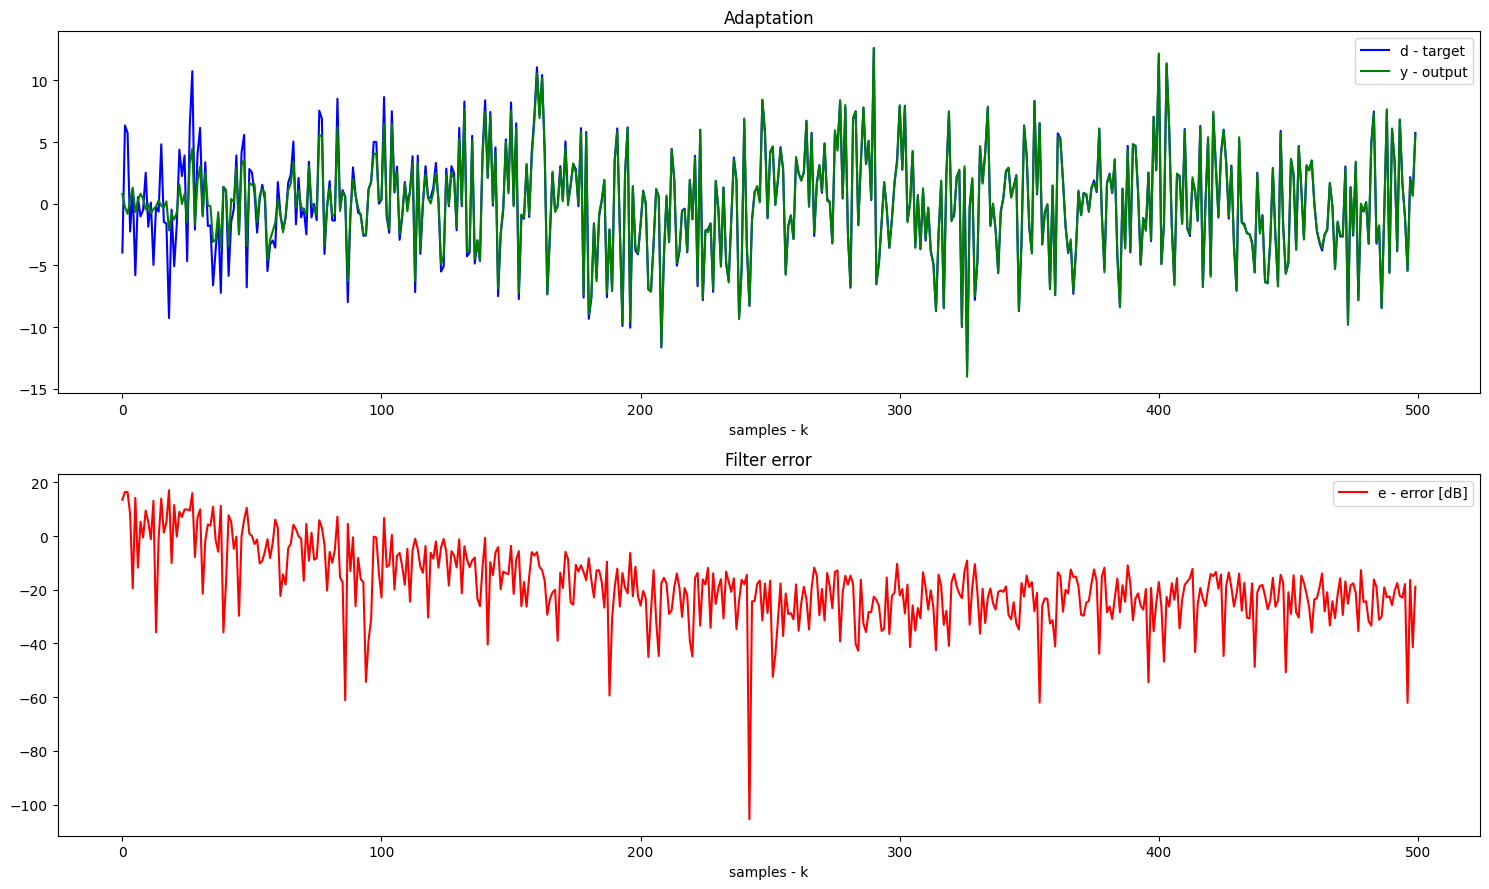

In [1]:
import numpy as np
import matplotlib.pylab as plt
import padasip as pa

# creation of data
N = 500
x = np.random.normal(0, 1, (N, 4)) # input matrix
v = np.random.normal(0, 0.1, N) # noise
d = 2*x[:,0] + 0.1*x[:,1] - 4*x[:,2] + 0.5*x[:,3] + v # target

f = pa.filters.FilterNLMS(n=4, mu=0.1, w="random")
y, e, w = f.run(d, x)

plt.figure(figsize=(15,9))
plt.subplot(211);plt.title("Adaptation");plt.xlabel("samples - k")
plt.plot(d,"b", label="d - target")
plt.plot(y,"g", label="y - output");plt.legend()
plt.subplot(212);plt.title("Filter error");plt.xlabel("samples - k")
plt.plot(10*np.log10(e**2),"r", label="e - error [dB]");plt.legend()
plt.tight_layout()
plt.show()

✅ Saved filtered_output.txt

📊 Initial SNR (Noisy): 4.88 dB
📊 Final SNR (Filtered): 13.12 dB


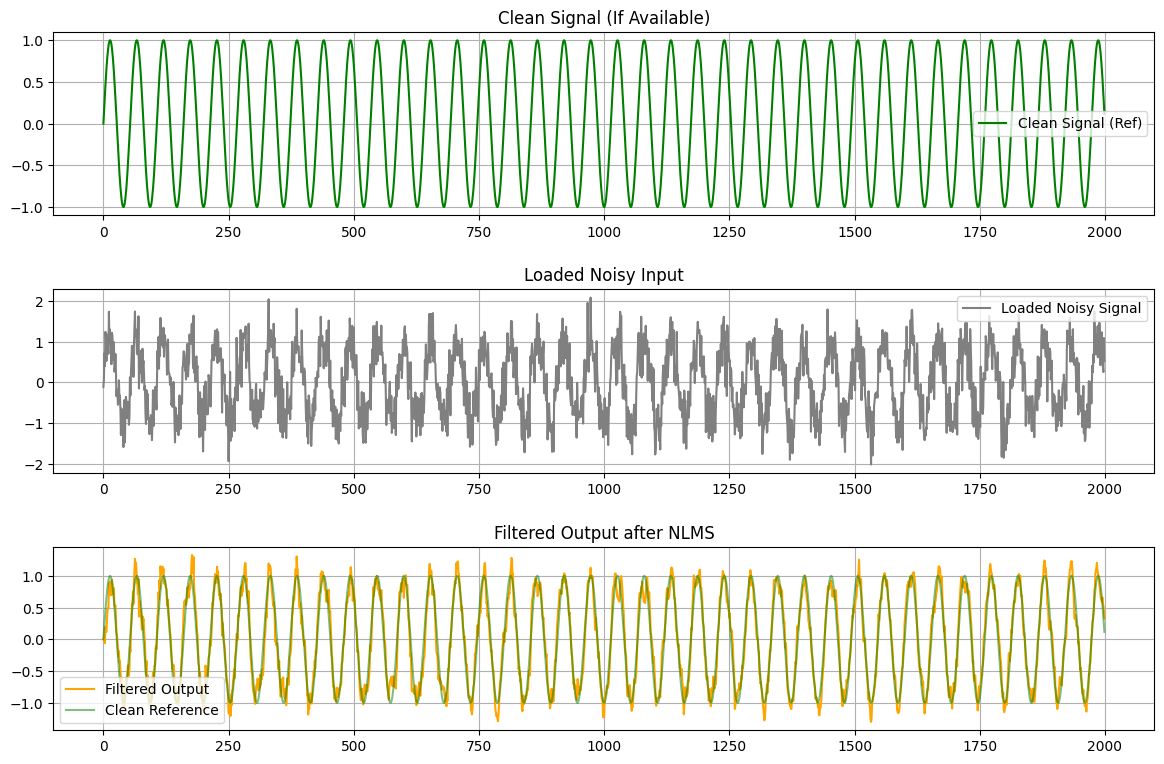

In [ ]:
# -----------------------------
# NLMS adaptive filter step
# -----------------------------
def nlms_step(x_vec, d, w, mu=0.1, eps=1e-6):
    y = np.dot(w, x_vec)
    e = d - y
    norm_factor = np.dot(x_vec, x_vec) + eps
    w = w + (mu / norm_factor) * e * x_vec
    return y, e, w

# -----------------------------
# Compute SNR utility
# -----------------------------
def snr(signal, reference):
    power_signal = np.mean(reference**2)
    power_noise = np.mean((reference - signal)**2)
    return 10 * np.log10(power_signal / (power_noise + 1e-12))

# -----------------------------
# Main NLMS simulation pipeline
# -----------------------------
def nlms_pipeline(fs=16000, duration=0.5, N=16, mu=0.2, noise_gain=0.4, mode="generate"):
    t = np.arange(0, duration, 1/fs)
    f0 = 300
    clean = np.sin(2 * np.pi * f0 * t)
    show_samples = min(2000, len(clean))

    # ========================================================
    # MODE 1: GENERATE NEW SIGNAL, SAVE, FILTER, AND PLOT
    # ========================================================
    if mode == "generate":
        print("🎵 Generating new clean + noisy signals...")
        noise = noise_gain * np.random.randn(len(t))
        noisy = clean + noise

        # Save both signals
        np.savetxt("../data/clean_signal.txt", clean, fmt="%.6f")
        np.savetxt("../data/noisy_signal.txt", noisy, fmt="%.6f")
        print("✅ Saved: clean_signal.txt, noisy_signal.txt")

        # Run NLMS filtering
        w = np.zeros(N)
        x_buf = np.zeros(N)
        y_out = np.zeros_like(noisy)

        for n in range(len(noisy)):
            x_buf[1:] = x_buf[:-1]
            x_buf[0] = noisy[n]
            y, e, w = nlms_step(x_buf, clean[n], w, mu)
            y_out[n] = y

        np.savetxt("../data/filtered_output.txt", y_out, fmt="%.6f")
        print("✅ Saved filtered_output.txt")

        snr_noisy = snr(noisy, clean)
        snr_filtered = snr(y_out, clean)
        print(f"\n📊 Initial SNR (Noisy): {snr_noisy:.2f} dB")
        print(f"📊 Final SNR (Filtered): {snr_filtered:.2f} dB")
        print(f"📈 SNR Improvement: {snr_filtered - snr_noisy:.2f} dB")

        # Plot
        plt.figure(figsize=(12, 8))
        plt.subplot(3, 1, 1)
        plt.plot(clean[:show_samples], 'g', label="Clean Signal")
        plt.title("Clean Signal")
        plt.grid(True)
        plt.legend()

        plt.subplot(3, 1, 2)
        plt.plot(noisy[:show_samples], 'gray', label=f"Noisy (SNR={snr_noisy:.2f} dB)")
        plt.title("Noisy Input")
        plt.grid(True)
        plt.legend()

        plt.subplot(3, 1, 3)
        plt.plot(y_out[:show_samples], 'orange', label=f"Filtered Output (SNR={snr_filtered:.2f} dB)")
        plt.plot(clean[:show_samples], 'g', alpha=0.5, label="Clean Reference")
        plt.title("Filtered Output")
        plt.grid(True)
        plt.legend()

        plt.tight_layout(pad=2)
        plt.show()
        return

    # ========================================================
    # MODE 2: LOAD EXISTING NOISY SIGNAL, FILTER, AND PLOT
    # ========================================================
    elif mode == "load_noisy":
        if not os.path.exists("../data/noisy_signal.txt"):
            raise FileNotFoundError("❌ 'noisy_signal.txt' not found! Run mode='generate' first.")

        noisy = np.loadtxt("../data/noisy_signal.txt")

        # If clean reference exists, use it for SNR
        clean = np.loadtxt("../data/clean_signal.txt") if os.path.exists("../data/clean_signal.txt") else np.zeros_like(noisy)
        min_len = min(len(noisy), len(clean))
        noisy, clean = noisy[:min_len], clean[:min_len]

        # Filter
        w = np.zeros(N)
        x_buf = np.zeros(N)
        y_out = np.zeros_like(noisy)

        for n in range(min_len):
            x_buf[1:] = x_buf[:-1]
            x_buf[0] = noisy[n]
            y, e, w = nlms_step(x_buf, clean[n], w, mu)
            y_out[n] = y

        np.savetxt("../data/filtered_output.txt", y_out, fmt="%.6f")
        print("✅ Saved filtered_output.txt")

        snr_noisy = snr(noisy, clean)
        snr_filtered = snr(y_out, clean)

        print(f"\n📊 Initial SNR (Noisy): {snr_noisy:.2f} dB")
        print(f"📊 Final SNR (Filtered): {snr_filtered:.2f} dB")

        plt.figure(figsize=(12, 8))
        plt.subplot(3, 1, 1)
        plt.plot(clean[:show_samples], 'g', label="Clean Signal (Ref)")
        plt.title("Clean Signal (If Available)")
        plt.grid(True)
        plt.legend()

        plt.subplot(3, 1, 2)
        plt.plot(noisy[:show_samples], 'gray', label="Loaded Noisy Signal")
        plt.title("Loaded Noisy Input")
        plt.grid(True)
        plt.legend()

        plt.subplot(3, 1, 3)
        plt.plot(y_out[:show_samples], 'orange', label="Filtered Output")
        plt.plot(clean[:show_samples], 'g', alpha=0.5, label="Clean Reference")
        plt.title("Filtered Output after NLMS")
        plt.grid(True)
        plt.legend()

        plt.tight_layout(pad=2)
        plt.show()
        return

    # ========================================================
    # MODE 3: LOAD NOISY + CLEAN SIGNAL AND COMPARE (AFTER HLS)
    # ========================================================
    elif mode == "plot_compare":
        if not os.path.exists("../data/filtered_output.txt") or not os.path.exists("../data/clean_signal.txt"):
            raise FileNotFoundError("❌ Missing 'filtered_output.txt' or 'clean_signal.txt'.")

        clean = np.loadtxt("clean_signal.txt")
        filtered = np.loadtxt("filtered_output.txt")
        noisy = np.loadtxt("../data/noisy_signal.txt") if os.path.exists("../data/noisy_signal.txt") else None

        min_len = min(len(filtered), len(clean))
        filtered, clean = filtered[:min_len], clean[:min_len]
        if noisy is not None:
            noisy = noisy[:min_len]

        snr_filtered = snr(filtered, clean)
        print(f"📈 SNR(Filtered vs Clean): {snr_filtered:.2f} dB")

        plt.figure(figsize=(12, 8))
        if noisy is not None:
            plt.subplot(3, 1, 1)
            plt.plot(noisy[:show_samples], 'gray', label="Noisy Input")
            plt.title("Noisy Input")
            plt.grid(True)
            plt.legend()

            plt.subplot(3, 1, 2)
            plt.plot(clean[:show_samples], 'g', label="Clean Reference")
            plt.title("Clean Reference")
            plt.grid(True)
            plt.legend()

            plt.subplot(3, 1, 3)
        else:
            plt.subplot(2, 1, 1)
            plt.plot(clean[:show_samples], 'g', label="Clean Reference")
            plt.title("Clean Reference")
            plt.grid(True)
            plt.legend()

            plt.subplot(2, 1, 2)

        plt.plot(filtered[:show_samples], 'orange', label=f"Filtered Output (SNR={snr_filtered:.2f} dB)")
        plt.plot(clean[:show_samples], 'g', alpha=0.5, label="Clean Reference")
        plt.title("Filtered Output vs Clean (HLS Comparison)")
        plt.grid(True)
        plt.legend()

        plt.tight_layout(pad=2)
        plt.show()
        return

    else:
        raise ValueError("❌ Invalid mode. Choose from ['generate', 'load_noisy', 'plot_compare'].")


# mode = "generate"      # Generate new noisy signal, filter, plot
mode = "load_noisy"    # Load existing noisy signal, filter, plot
# mode = "plot_compare"    # Load noisy + clean (from HLS) and compare

nlms_pipeline(mode=mode)
